# Task 5B: Impact of Evaluation Metrics

This notebook applies MSE and MAE as evaluation metrics to the regression problem of Task 4 (next-day mood prediction).
To keep the story consistent with the report's Chapter 5, we reuse the Task 4 pipeline exactly: the same cleaning,
the same 96-feature matrix, the same leave-five-patients-out split, and the same Gradient Boosting hyperparameters
selected by the Task 4 grid search.

The question this section answers is: what happens to the model when the choice of MSE and MAE is pushed from
the evaluation step into the training step? We train the same regressor twice, once minimising squared error
(MSE) and once minimising absolute error (MAE), and compare the two resulting models on MSE and MAE.


In [1]:
# === Setup: same imports and constants as Task 4 ===
import sys, os, warnings, gc
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from shared.data_loader import load_and_clean, get_split
from shared.feature_builder import build_features
from config import RANDOM_SEED, ID_COL, DATE_COL, TARGET_COL

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 10})

FIG_DIR = Path('../../Assignment 1 (Advanced)/report/figures_task5b')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Data and features (identical to Task 4)

Load the raw long-format CSV, pivot to daily wide format, clean with IQR (multiplier 3.0), impute with linear
interpolation, add morning and evening mood, drop sparse app columns. Then build the 96-dimensional feature
matrix: 7-day rolling statistics (mean, std, min, max, trend), five mood lags, volatility, interactions,
momentum and lagged valence, with durations log-transformed before aggregation.


In [2]:
daily = load_and_clean(
    outlier_method='iqr', iqr_multiplier=3.0,
    imputation_method='linear',
    drop_sparse=True, add_morning_evening=True,
    log_transform_durations=False,
)

features_df = build_features(
    daily, window_sizes=[7], n_lags=5,
    agg_functions=['mean', 'std', 'min', 'max', 'trend'],
    include_volatility=True, include_interactions=True,
    include_momentum=True, include_lagged_valence=True,
    log_transform_before_agg=True,
)

meta_cols = [ID_COL, DATE_COL, TARGET_COL]
feature_cols = [c for c in features_df.columns if c not in meta_cols]
print(f'Instances: {len(features_df)}, Features: {len(feature_cols)}')

  Phase 1: Data Cleaning


    Raw daily: 2154 rows, 21 columns, 27 patients
    IQR outliers removed (multiplier=3.0): 335
    Imputation: linear interpolation


    Added mood_morning, mood_evening, mood_intraday_slope
    Dropped 7 sparse app columns (>80% missing)
    Final cleaned: 2154 rows, 17 cols, 27 patients
  Phase 2: Feature Engineering
    Log-transformed duration variables before aggregation


    Instances: 1965, Features: 96
    Window: [7], Lags: 5, Aggs: ['mean', 'std', 'min', 'max', 'trend']
Instances: 1965, Features: 96


## 2. Split (same 5 hold-out patients as Task 4)

`get_split` with `method='leave_patients_out'` and `seed=42` yields the canonical holdout
`{AS14.01, AS14.12, AS14.13, AS14.17, AS14.28}` used throughout the report.


In [3]:
train, test = get_split(
    features_df, method='leave_patients_out',
    n_holdout_patients=5, seed=RANDOM_SEED
)

X_train = np.nan_to_num(train[feature_cols].values, nan=0)
X_test  = np.nan_to_num(test[feature_cols].values, nan=0)
y_train = train[TARGET_COL].values
y_test  = test[TARGET_COL].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(train)} instances / {train[ID_COL].nunique()} patients')
print(f'Test:  {len(test)} instances / {test[ID_COL].nunique()} patients')
print(f'Hold-out patients: {sorted(test[ID_COL].unique())}')

    Leave-patients-out: 5 patients held out: ['AS14.12', 'AS14.17', 'AS14.13', 'AS14.28', 'AS14.01']
Train: 1610 instances / 22 patients
Test:  355 instances / 5 patients
Hold-out patients: ['AS14.01', 'AS14.12', 'AS14.13', 'AS14.17', 'AS14.28']


## 3. Two GBRs that differ only in their loss function

Hyperparameters are the ones selected by the Task 4 grid search
(`learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8`). Only the `loss` argument is varied:
`squared_error` for the MSE-minimiser and `absolute_error` for the MAE-minimiser. The MSE-minimiser is
*the same model as the Gradient Boosting regressor reported in Chapter 5 of the report*.


In [4]:
BEST_PARAMS = dict(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, random_state=RANDOM_SEED,
)

gb_mse = GradientBoostingRegressor(loss='squared_error',  **BEST_PARAMS).fit(X_train_s, y_train)
gb_mae = GradientBoostingRegressor(loss='absolute_error', **BEST_PARAMS).fit(X_train_s, y_train)

pred_mse = gb_mse.predict(X_test_s)
pred_mae = gb_mae.predict(X_test_s)
print('Both models trained.')

Both models trained.


## 4. Results: MSE and MAE on the held-out patients


In [5]:
def metrics(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
    }

table = pd.DataFrame({
    'GBR trained with MSE loss': metrics(y_test, pred_mse),
    'GBR trained with MAE loss': metrics(y_test, pred_mae),
}).round(4)
print(table.to_string())

     GBR trained with MSE loss  GBR trained with MAE loss
MSE                     0.2693                     0.4179
MAE                     0.3431                     0.4864


## 5. Residual analysis

Residuals on the held-out patients, comparing the two models. The histogram shows the distribution shape;
the boxplot highlights the spread and the count of unusually large misses. The figure is saved to the
report's `Figures/` folder so Chapter 6 can include it.


|residual| > 1 mood point: MSE-trained = 29 (8%); MAE-trained = 42 (12%)


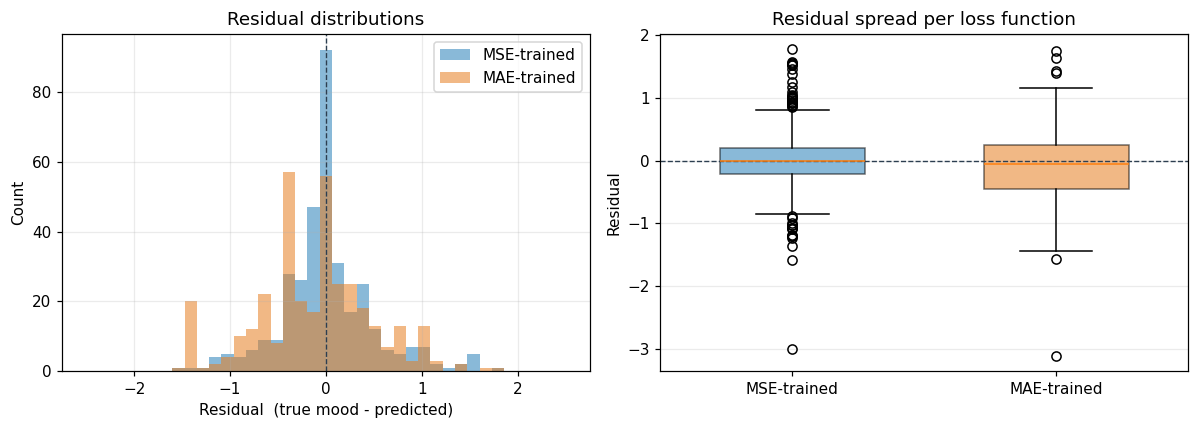

Figure saved to ../../Assignment 1 (Advanced)/report/figures_task5b/metric_impact_residuals.png


In [6]:
resid_mse = y_test - pred_mse
resid_mae = y_test - pred_mae

big = lambda r, t=1.0: int(np.sum(np.abs(r) > t))
print(f'|residual| > 1 mood point: MSE-trained = {big(resid_mse)} '
      f'({big(resid_mse)/len(resid_mse):.0%}); '
      f'MAE-trained = {big(resid_mae)} ({big(resid_mae)/len(resid_mae):.0%})')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bins = np.linspace(-2.5, 2.5, 40)
axes[0].hist(resid_mse, bins=bins, alpha=0.55, color='#2980b9', label='MSE-trained')
axes[0].hist(resid_mae, bins=bins, alpha=0.55, color='#e67e22', label='MAE-trained')
axes[0].axvline(0, color='#2c3e50', linestyle='--', linewidth=0.9)
axes[0].set_xlabel('Residual  (true mood - predicted)')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual distributions')
axes[0].legend()
axes[0].grid(alpha=0.25)

bp = axes[1].boxplot([resid_mse, resid_mae], patch_artist=True, widths=0.55,
                      tick_labels=['MSE-trained', 'MAE-trained'])
for patch, c in zip(bp['boxes'], ['#2980b9', '#e67e22']):
    patch.set_facecolor(c); patch.set_alpha(0.55)
axes[1].axhline(0, color='#2c3e50', linestyle='--', linewidth=0.9)
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual spread per loss function')
axes[1].grid(alpha=0.25, axis='y')

fig.tight_layout()
fig.savefig(FIG_DIR / 'metric_impact_residuals.png', bbox_inches='tight')
plt.show()
print('Figure saved to', FIG_DIR / 'metric_impact_residuals.png')

## 6. Implications

1. The MSE-minimiser (the model reported in Chapter 5) is also the stronger model when we now re-evaluate
   using both MSE and MAE. This is expected: the mood target is bounded in [1, 10] and concentrated within one
   standard deviation of 7.05, so the absolute-error minimiser collapses towards the median predictor, which
   on this dataset is very close to the mean predictor. The MAE-trained model ends up flatter across patients,
   losing the variance information the MSE-trained model retains.

2. The residual comparison is more informative than the aggregate metrics. The MSE-trained model produces
   fewer residuals with absolute value above one mood point; those are precisely the misses that matter for a
   self-monitoring application, where predicting mood 7 on a day where the true value is 5 is clinically
   dangerous.

3. For model selection on this dataset, MSE is therefore the better criterion. For reporting, MAE remains the
   more useful metric because its units are directly interpretable (mean mood points off). The report therefore
   continues to show both, but trains and selects models on squared error.
